In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso , ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error , r2_score
import pickle
from sklearn.preprocessing import OneHotEncoder

In [4]:
#load Data Set

calories = pd.read_csv("calories.csv")
excercise = pd.read_csv("exercise.csv")

In [5]:
print("Calories Shape :",calories.shape)
print("Excercise Shape :",excercise.shape)

Calories Shape : (15000, 2)
Excercise Shape : (15000, 8)


In [6]:
print(calories.head())

    User_ID  Calories
0  14733363     231.0
1  14861698      66.0
2  11179863      26.0
3  16180408      71.0
4  17771927      35.0


In [7]:
print(calories.head())
print(excercise.head())

    User_ID  Calories
0  14733363     231.0
1  14861698      66.0
2  11179863      26.0
3  16180408      71.0
4  17771927      35.0
    User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8


In [8]:
#merge dataset

df = excercise.merge(calories , on="User_ID",how="inner")
print("Merged Shape :",df.shape)
print(df.head())

Merged Shape : (15000, 9)
    User_ID  Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  \
0  14733363    male   68   190.0    94.0      29.0       105.0       40.8   
1  14861698  female   20   166.0    60.0      14.0        94.0       40.3   
2  11179863    male   69   179.0    79.0       5.0        88.0       38.7   
3  16180408  female   34   179.0    71.0      13.0       100.0       40.5   
4  17771927  female   27   154.0    58.0      10.0        81.0       39.8   

   Calories  
0     231.0  
1      66.0  
2      26.0  
3      71.0  
4      35.0  


In [9]:
#understand data

print("Columns :",df.columns.tolist())

Columns : ['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp', 'Calories']


In [10]:
print("Data Types :")
print(df.dtypes)

Data Types :
User_ID         int64
Gender            str
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object


In [11]:
print("Missing Values :")
print(df.isnull().sum())

Missing Values :
User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64


In [12]:
print("Summary Statistics :")
print(df.describe())

Summary Statistics :
            User_ID           Age        Height        Weight      Duration  \
count  1.500000e+04  15000.000000  15000.000000  15000.000000  15000.000000   
mean   1.497736e+07     42.789800    174.465133     74.966867     15.530600   
std    2.872851e+06     16.980264     14.258114     15.035657      8.319203   
min    1.000116e+07     20.000000    123.000000     36.000000      1.000000   
25%    1.247419e+07     28.000000    164.000000     63.000000      8.000000   
50%    1.499728e+07     39.000000    175.000000     74.000000     16.000000   
75%    1.744928e+07     56.000000    185.000000     87.000000     23.000000   
max    1.999965e+07     79.000000    222.000000    132.000000     30.000000   

         Heart_Rate     Body_Temp      Calories  
count  15000.000000  15000.000000  15000.000000  
mean      95.518533     40.025453     89.539533  
std        9.583328      0.779230     62.456978  
min       67.000000     37.100000      1.000000  
25%       88.0000

In [13]:
print("Total User IDs:", df["User_ID"].nunique())
print("Duplicate User IDs:", df["User_ID"].duplicated().sum())

Total User IDs: 15000
Duplicate User IDs: 0


In [14]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [15]:
print("Shape:", df.shape)

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nDuplicate User IDs:")
print(df["User_ID"].duplicated().sum())

print("\nUnique User IDs:")
print(df["User_ID"].nunique())

print("\nColumns:")
print(df.columns)

Shape: (15000, 9)

Duplicate rows:
0

Duplicate User IDs:
0

Unique User IDs:
15000

Columns:
Index(['User_ID', 'Gender', 'Age', 'Height', 'Weight', 'Duration',
       'Heart_Rate', 'Body_Temp', 'Calories'],
      dtype='str')


In [16]:
df = df.drop("User_ID", axis=1)

In [17]:
print(df.head())

   Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp  Calories
0    male   68   190.0    94.0      29.0       105.0       40.8     231.0
1  female   20   166.0    60.0      14.0        94.0       40.3      66.0
2    male   69   179.0    79.0       5.0        88.0       38.7      26.0
3  female   34   179.0    71.0      13.0       100.0       40.5      71.0
4  female   27   154.0    58.0      10.0        81.0       39.8      35.0


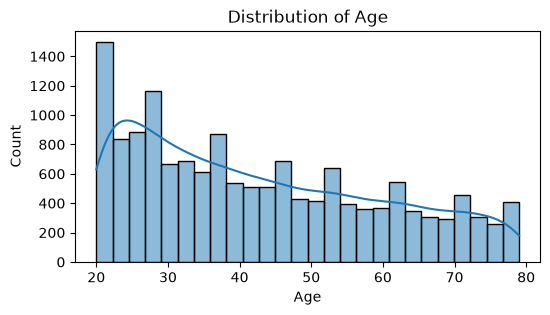

In [18]:
#EDA

plt.figure(figsize = (6,3))
sns.histplot(df["Age"],kde = True)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.show()

#Age is distributed between approximately 20 and 79 years. The dataset contains a higher number of younger participants,
# while the frequency generally decreases with increasing age, resulting in a right-skewed distribution.

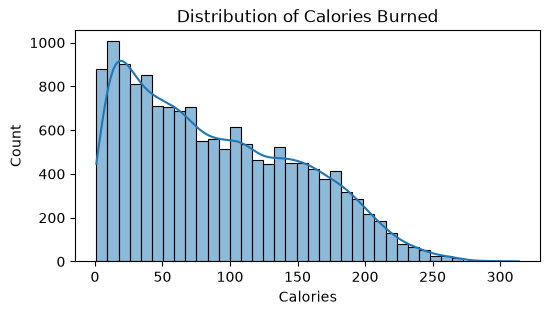

In [19]:
plt.figure(figsize = (6,3))
sns.histplot(df["Calories"],kde = True)
plt.title("Distribution of Calories Burned")
plt.xlabel("Calories")
plt.show()

#The distribution of calories burned is positively skewed. 
# Most observations have relatively low calorie values, 
# while fewer observations have higher calorie values, creating a long right tail.

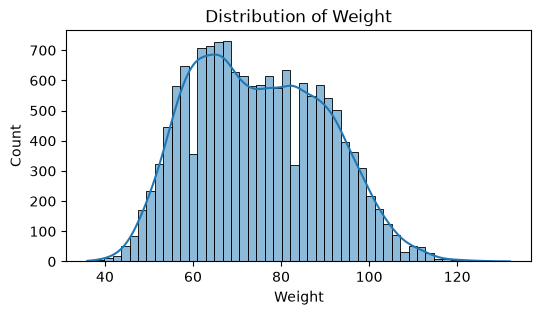

In [20]:
plt.figure(figsize = (6,3))
sns.histplot(df["Weight"],kde = True)
plt.title("Distribution of Weight")
plt.xlabel("Weight")
plt.show()

#Weight ranges approximately from 40 kg to 120 kg, with most observations concentrated between 55 kg and 95 kg. 
# The distribution is approximately bell-shaped, with fewer observations at very low and very high weights.

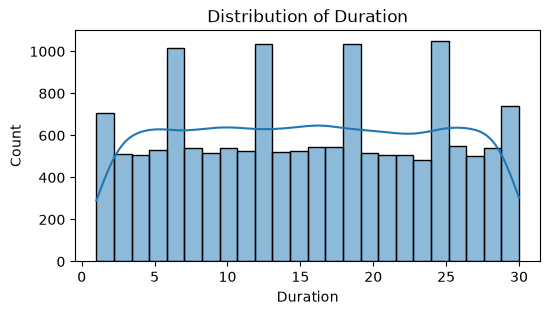

In [21]:
plt.figure(figsize = (6,3))
sns.histplot(df["Duration"],kde = True)
plt.title("Distribution of Duration")
plt.xlabel("Duration")
plt.show()

#Exercise duration ranges from approximately 1 to 30 minutes. The observations are relatively evenly distributed across the range, 
# with noticeable peaks around 6, 12, 18, and 24 minutes. No extreme values are observed.

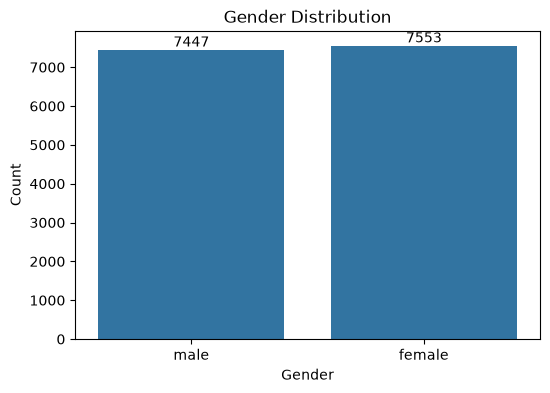

In [22]:
plt.figure(figsize=(6,4))

ax = sns.countplot(x="Gender", data=df)

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container)

plt.show()

#The dataset contains 7,447 male and 7,553 female observations. 
# The gender distribution is almost balanced, with female observations being slightly higher than male observations.

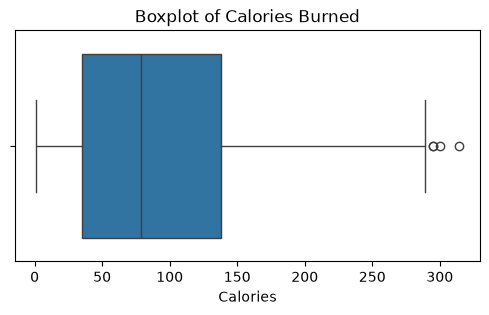

In [23]:
plt.figure(figsize=(6,3))

sns.boxplot(x=df["Calories"])

plt.title("Boxplot of Calories Burned")
plt.xlabel("Calories")

plt.show()

#The boxplot shows that most calorie values are concentrated below approximately 140 calories. 
# A few high-calorie observations above 300 calories are identified as potential outliers, indicating a right-skewed distribution.

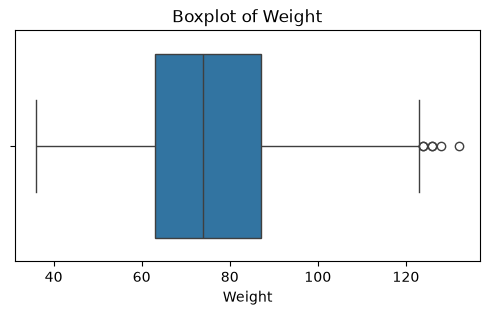

In [24]:
plt.figure(figsize = (6,3))
sns.boxplot(x = df["Weight"])
plt.title("Boxplot of Weight")
plt.xlabel("Weight")
plt.show()



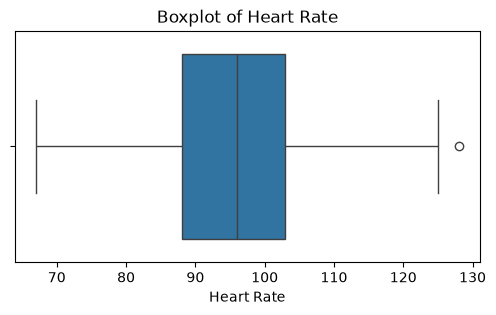

In [25]:
plt.figure(figsize = (6,3))
sns.boxplot(x = df["Heart_Rate"])
plt.title("Boxplot of Heart Rate")
plt.xlabel("Heart Rate")
plt.show()

#Heart rate is mainly concentrated between approximately 88 and 103, with a median around 97. 
# The boxplot identifies one potential high-value outlier around 127–128.

In [26]:
print("Median Heart Rate:", df["Heart_Rate"].median())

Q1 = df["Heart_Rate"].quantile(0.25)
Q3 = df["Heart_Rate"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers = df[
    (df["Heart_Rate"] < lower_limit) |
    (df["Heart_Rate"] > upper_limit)
]["Heart_Rate"]

print("Outliers:", outliers.tolist())


Median Heart Rate: 96.0
Outliers: [128.0]


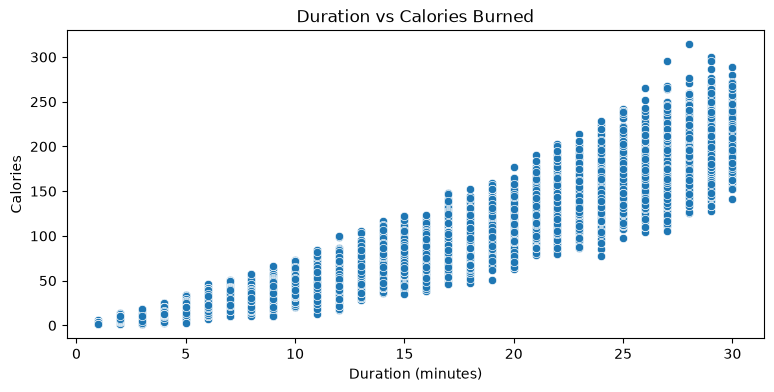

In [27]:
plt.figure(figsize=(9,4))

sns.scatterplot(x="Duration", y="Calories", data=df)

plt.title("Duration vs Calories Burned")
plt.xlabel("Duration (minutes)")
plt.ylabel("Calories")

plt.show()

#The scatterplot shows a strong positive relationship between exercise duration and calories burned. 
# As exercise duration increases, calories burned generally increase.

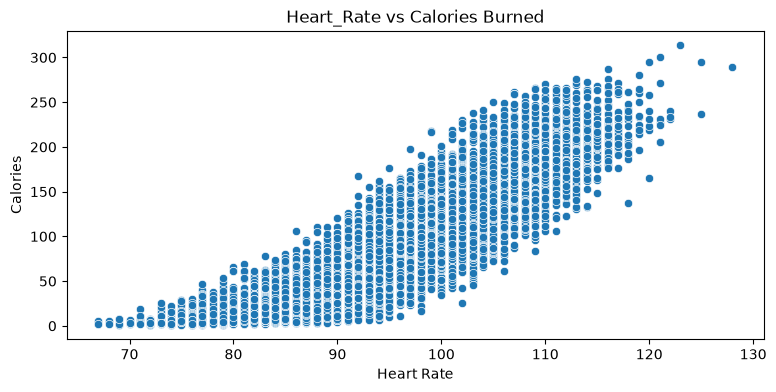

In [28]:
plt.figure(figsize=(9,4))

sns.scatterplot(x="Heart_Rate", y="Calories", data=df)

plt.title("Heart_Rate vs Calories Burned")
plt.xlabel("Heart Rate")
plt.ylabel("Calories")

plt.show()

#The scatterplot shows a strong positive relationship between heart rate and calories burned. As heart rate increases, 
# calories burned generally increase.

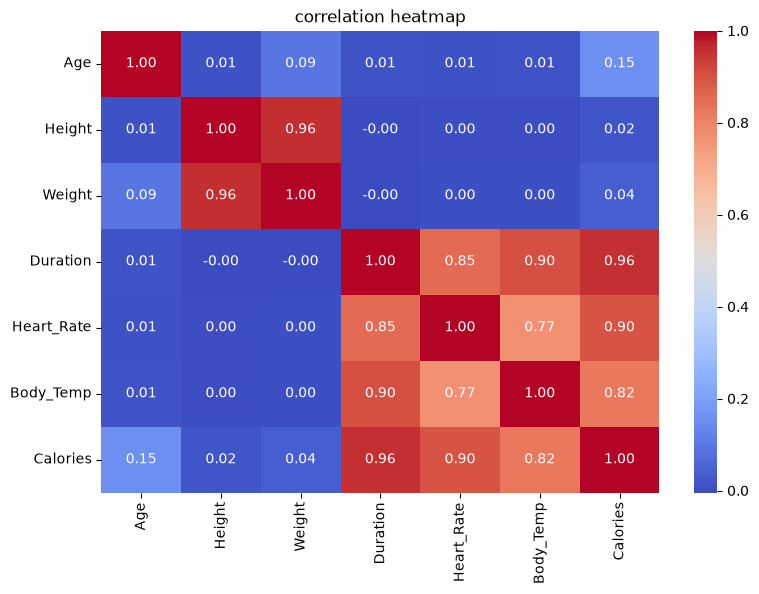

In [29]:
plt.figure(figsize = (9,6))
sns.heatmap(
    df.select_dtypes(include = np.number).corr(),
    annot = True,
    fmt = ".2f",
    cmap = "coolwarm"
)
plt.title("correlation heatmap")
plt.show()

#Duration has the strongest correlation with Calories (0.96).

#This agrees with the scatterplot you created earlier:

#As exercise duration increases, calories burned generally increase.

#Heart_Rate is also strongly correlated (0.90) and Body_Temp has a strong positive correlation (0.82).

In [30]:
encoder = OneHotEncoder(drop="first", sparse_output=False)

gender_encoded = encoder.fit_transform(df[["Gender"]])

df["Gender"] = gender_encoded.astype(int)

In [31]:
df.head()

,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,1,68,190.0,94.0,29.0,105.0,40.8,231.0
1,0,20,166.0,60.0,14.0,94.0,40.3,66.0
2,1,69,179.0,79.0,5.0,88.0,38.7,26.0
3,0,34,179.0,71.0,13.0,100.0,40.5,71.0
4,0,27,154.0,58.0,10.0,81.0,39.8,35.0


In [32]:
df.dtypes

Gender          int64
Age             int64
Height        float64
Weight        float64
Duration      float64
Heart_Rate    float64
Body_Temp     float64
Calories      float64
dtype: object

In [33]:
#seperate x and y

x = df.drop(columns = ["Calories"])
y = df["Calories"]

In [34]:
# Train Test Split

xtrain , xtest , ytrain , ytest = train_test_split(x,y,test_size = 0.20 , random_state = 42)
print("Training Data :",xtrain.shape)
print("Testing Data :",xtest.shape)

Training Data : (12000, 7)
Testing Data : (3000, 7)


In [35]:
#Feature Scaling
# Scale after splitting
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(xtrain)
X_test_scaled = scaler.transform(xtest)


In [36]:
X_train_scaled

array([[ 1.00719253, -0.33729461,  0.32323185, ..., -1.02188864,
        -1.51737651, -0.67103106],
       [ 1.00719253, -1.16332224,  1.44792406, ...,  1.26666332,
         1.52242538,  0.61448958],
       [ 1.00719253, -0.57330251,  0.46381838, ..., -0.41963812,
        -0.78363123,  0.10028132],
       ...,
       [ 1.00719253,  0.84274485,  1.02616448, ..., -0.90143854,
        -0.57398972, -0.67103106],
       [ 1.00719253, -0.45529856, -0.02823446, ..., -0.41963812,
         0.15975557,  0.22883339],
       [ 1.00719253, -0.98631632,  0.53411164, ...,  0.06216229,
        -0.46916896,  0.61448958]], shape=(12000, 7))

In [37]:
#Linear Regrssion

lr = LinearRegression()
lr.fit(X_train_scaled,ytrain)
ypred = lr.predict(X_test_scaled)

In [38]:
#Evaluate the model
print("MAE :",mean_absolute_error(ytest,ypred))
print("MSE :",mean_squared_error(ytest, ypred))
print("RMSE :",np.sqrt(mean_squared_error(ytest,ypred)))
print("R2 Score :",r2_score(ytest,ypred))

MAE : 8.441513553849704
MSE : 131.99574575081695
RMSE : 11.488940149152878
R2 Score : 0.9672937151257295


In [39]:
#Polynomial Regression

from sklearn.preprocessing import PolynomialFeatures

#Create degree-2 polynomial features:
poly = PolynomialFeatures(degree=2)

xtrain_poly = poly.fit_transform(X_train_scaled)
xtest_poly = poly.transform(X_test_scaled)

poly_model = LinearRegression()

poly_model.fit(xtrain_poly, ytrain)
ypred_poly = poly_model.predict(xtest_poly)

In [40]:
mae_poly = mean_absolute_error(ytest, ypred_poly)
mse_poly = mean_squared_error(ytest, ypred_poly)
rmse_poly = np.sqrt(mse_poly)
r2_poly = r2_score(ytest, ypred_poly)

print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("R2 Score :", r2_poly)

MAE : 2.2502323562164084
MSE : 9.220467111748475
RMSE : 3.0365222066944404
R2 Score : 0.9977153261848303


In [41]:
train_pred = poly_model.predict(xtrain_poly)
test_pred = poly_model.predict(xtest_poly)

print("Training R2:", r2_score(ytrain, train_pred))
print("Testing R2:", r2_score(ytest, test_pred))

Training R2: 0.9977083690828762
Testing R2: 0.9977153261848303


In [42]:
ridge_model = Ridge(alpha = 1)
ridge_model.fit(X_train_scaled,ytrain)
ridge_pred = ridge_model.predict(X_test_scaled)

In [43]:
ridge_mae = mean_absolute_error(ytest, ridge_pred)
ridge_mse = mean_squared_error(ytest, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)
ridge_r2 = r2_score(ytest, ridge_pred)

print("MAE :", ridge_mae)
print("MSE :", ridge_mse)
print("RMSE :", ridge_rmse)
print("R2 Score :", ridge_r2)

MAE : 8.441186197335304
MSE : 132.0019414005324
RMSE : 11.489209781378891
R2 Score : 0.9672921799498538


In [44]:
poly = PolynomialFeatures(degree=2)

xtrain_poly = poly.fit_transform(X_train_scaled)
xtest_poly = poly.transform(X_test_scaled)

ridge_poly = Ridge(alpha=1)

ridge_poly.fit(xtrain_poly, ytrain)

ridge_poly_pred = ridge_poly.predict(xtest_poly)

In [45]:
best_alpha = None
best_mse = float("inf")

for alpha in range(1,30):

    ridge_model = Ridge(alpha=alpha)

    ridge_model.fit(xtrain_poly, ytrain)

    ridge_pred = ridge_model.predict(xtest_poly)

    mse = mean_squared_error(ytest, ridge_pred)

    print("Alpha:", alpha, "MSE:", mse)

    if mse < best_mse:
        best_mse = mse
        best_alpha = alpha

print("\nBest Alpha:", best_alpha)
print("Best MSE:", best_mse)

Alpha: 1 MSE: 9.220407877788697
Alpha: 2 MSE: 9.220719045106957
Alpha: 3 MSE: 9.221392371531053
Alpha: 4 MSE: 9.22242002910893
Alpha: 5 MSE: 9.22379456977228
Alpha: 6 MSE: 9.225508893383628
Alpha: 7 MSE: 9.22755621827532
Alpha: 8 MSE: 9.229930054376384
Alpha: 9 MSE: 9.232624178911685
Alpha: 10 MSE: 9.23563261455992
Alpha: 11 MSE: 9.23894960989527
Alpha: 12 MSE: 9.242569621908505
Alpha: 13 MSE: 9.246487300394937
Alpha: 14 MSE: 9.250697474003529
Alpha: 15 MSE: 9.255195137755235
Alpha: 16 MSE: 9.259975441855742
Alpha: 17 MSE: 9.265033681647127
Alpha: 18 MSE: 9.27036528856062
Alpha: 19 MSE: 9.275965821949146
Alpha: 20 MSE: 9.28183096169441
Alpha: 21 MSE: 9.287956501497131
Alpha: 22 MSE: 9.29433834276894
Alpha: 23 MSE: 9.300972489059077
Alpha: 24 MSE: 9.307855040953006
Alpha: 25 MSE: 9.314982191391769
Alpha: 26 MSE: 9.32235022136662
Alpha: 27 MSE: 9.329955495947887
Alpha: 28 MSE: 9.337794460614653
Alpha: 29 MSE: 9.345863637852862

Best Alpha: 1
Best MSE: 9.220407877788697


In [46]:
ridge_poly_model = Ridge(alpha = best_alpha)
ridge_poly_model.fit(xtrain_poly,ytrain)
ridge_poly_pred = ridge_poly_model.predict(xtest_poly)

In [47]:
mae = mean_absolute_error(ytest, ridge_poly_pred)
mse = mean_squared_error(ytest, ridge_poly_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, ridge_poly_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.2503519851929843
MSE : 9.220407877788697
RMSE : 3.0365124530929717
R2 Score : 0.997715340861991


In [48]:
from sklearn.linear_model import Lasso

alphas = [0.001, 0.01, 0.1, 1, 10, 100]

best_alpha = None
best_mse = float("inf")

for alpha in alphas:

    lasso_model = Lasso(alpha=alpha, max_iter=10000)

    lasso_model.fit(xtrain_poly, ytrain)

    lasso_pred = lasso_model.predict(xtest_poly)

    mse = mean_squared_error(ytest, lasso_pred)

    print("Alpha:", alpha, "MSE:", mse)

    if mse < best_mse:
        best_mse = mse
        best_alpha = alpha

print("Best Alpha:", best_alpha)
print("Best MSE:", best_mse)

Alpha: 0.001 MSE: 9.213716682707783
Alpha: 0.01 MSE: 9.21289330864558
Alpha: 0.1 MSE: 9.672098243372467
Alpha: 1 MSE: 20.472142098420097
Alpha: 10 MSE: 369.6321550395737
Alpha: 100 MSE: 4040.722467673611
Best Alpha: 0.01
Best MSE: 9.21289330864558


In [49]:
lasso_poly_model = Lasso(alpha=best_alpha, max_iter=10000)

lasso_poly_model.fit(xtrain_poly, ytrain)

lasso_poly_pred = lasso_poly_model.predict(xtest_poly)

mae = mean_absolute_error(ytest, lasso_poly_pred)
mse = mean_squared_error(ytest, lasso_poly_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, lasso_poly_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.248919716932952
MSE : 9.21289330864558
RMSE : 3.0352748324732604
R2 Score : 0.9977172028435094


In [50]:
tree_model = DecisionTreeRegressor(max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42)
tree_model.fit(xtrain,ytrain)
tree_pred = tree_model.predict(xtest)

In [51]:
mae = mean_absolute_error(ytest, tree_pred)
mse = mean_squared_error(ytest, tree_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, tree_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 3.955927700908726
MSE : 33.495383439351514
RMSE : 5.787519627556481
R2 Score : 0.9917004177179433


In [52]:
tree_train_pred = tree_model.predict(xtrain)
tree_test_pred = tree_model.predict(xtest)

print("Training R2:", r2_score(ytrain, tree_train_pred))
print("Testing R2:", r2_score(ytest, tree_test_pred))

Training R2: 0.9959489694152396
Testing R2: 0.9917004177179433


In [53]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators = 100,random_state = 42)
rf_model.fit(xtrain,ytrain)
rf_pred = rf_model.predict(xtest)

mae = mean_absolute_error(ytest, rf_pred)
mse = mean_squared_error(ytest, rf_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, rf_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 1.7173133333333332
MSE : 7.200538999999999
RMSE : 2.6833820078401063
R2 Score : 0.9982158297720679


In [54]:
rf_train_pred = rf_model.predict(xtrain)

print("Training R2:", r2_score(ytrain, rf_train_pred))
print("Testing R2:", r2_score(ytest, rf_pred))

Training R2: 0.9996877292400479
Testing R2: 0.9982158297720679


In [55]:
print(xtrain.columns)
print(xtest.columns)

Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='str')
Index(['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate',
       'Body_Temp'],
      dtype='str')


In [56]:
print("Calories" in xtrain.columns)
print("Calories" in xtest.columns)

False
False


In [57]:
print("Calories in X:", "Calories" in x.columns)

Calories in X: False


In [58]:
print(x.columns.tolist())

['Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


In [59]:
#check how your Calories are related to the features

print(df.corr(numeric_only=True)["Calories"].sort_values(ascending=False))

Calories      1.000000
Duration      0.955421
Heart_Rate    0.897882
Body_Temp     0.824558
Age           0.154395
Weight        0.035481
Gender        0.022357
Height        0.017537
Name: Calories, dtype: float64


In [60]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model = GradientBoostingRegressor(random_state=42)

gb_model.fit(xtrain,ytrain)
gb_model_pred = gb_model.predict(xtest)

mae = mean_absolute_error(ytest, gb_model_pred)
mse = mean_squared_error(ytest, gb_model_pred)
rmse = np.sqrt(mse)
r2 = r2_score(ytest, gb_model_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 2.605546971599344
MSE : 13.047498154876948
RMSE : 3.612132078825046
R2 Score : 0.9967670534446199


In [61]:
gb_train_pred =gb_model.predict(xtrain)
print("Training R2:", r2_score(ytrain, gb_train_pred))
print("Testing R2:", r2_score(ytest, gb_model_pred))

Training R2: 0.99686983204664
Testing R2: 0.9967670534446199


In [62]:
leaderboard = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Polynomial Regression",
        "Ridge + Polynomial",
        "Lasso + Polynomial",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    
    "MAE": [
        8.442,
        2.250,
        2.250,
        2.249,
        3.443,
        1.714,
        2.606
    ],
    
    "RMSE": [
        11.489,
        3.037,
        3.037,
        3.035,
        5.337,
        2.679,
        3.612
    ],
    
    "R2 Score": [
        0.96729,
        0.99772,
        0.99772,
        0.99772,
        0.99294,
        0.99822,
        0.99677
    ]
})

leaderboard = leaderboard.sort_values(
    by="R2 Score",
    ascending=False
)

print(leaderboard)

                   Model    MAE    RMSE  R2 Score
5          Random Forest  1.714   2.679   0.99822
2     Ridge + Polynomial  2.250   3.037   0.99772
1  Polynomial Regression  2.250   3.037   0.99772
3     Lasso + Polynomial  2.249   3.035   0.99772
6      Gradient Boosting  2.606   3.612   0.99677
4          Decision Tree  3.443   5.337   0.99294
0      Linear Regression  8.442  11.489   0.96729


In [63]:
from sklearn.model_selection import cross_val_score, KFold

In [64]:
kf = KFold(n_splits = 5 , shuffle = True , random_state = 42)
rf_cv_scores = cross_val_score(
    rf_model,
    x,
    y,
    cv=kf,
    scoring="r2"
)
print("R2 scores for each fold:", rf_cv_scores)
print("Mean R2:", rf_cv_scores.mean())
print("Standard Deviation:", rf_cv_scores.std())

R2 scores for each fold: [0.99818203 0.99776151 0.99807122 0.9978168  0.99765311]
Mean R2: 0.9978969321870934
Standard Deviation: 0.00019792205477408117


In [65]:
#understand which features are driving the Calories prediction.

importance = pd.Series(rf_model.feature_importances_,index = x.columns).sort_values(ascending=False)
print(importance)

Duration      0.913865
Heart_Rate    0.048346
Age           0.026338
Gender        0.006722
Weight        0.002977
Height        0.001248
Body_Temp     0.000505
dtype: float64


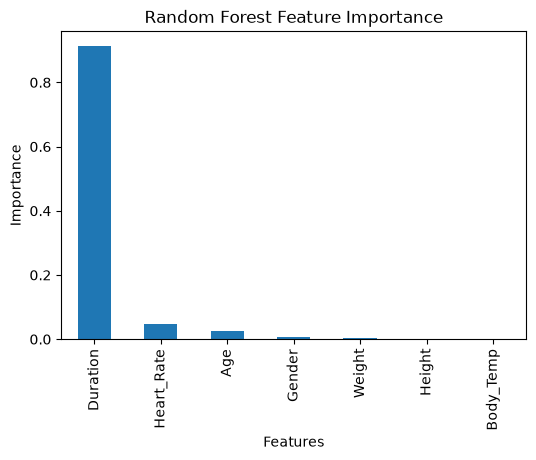

In [66]:
plt.figure(figsize = (6,4))
importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

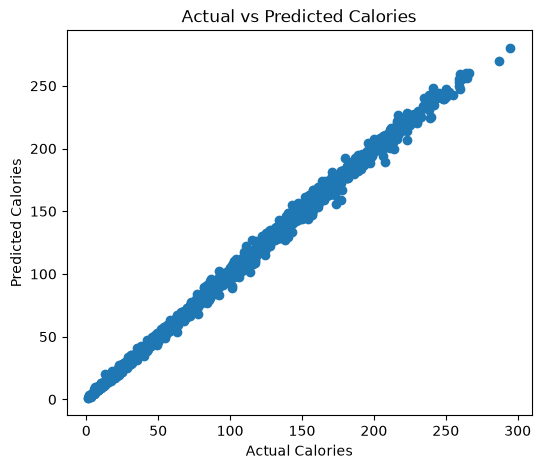

In [67]:
plt.figure(figsize=(6, 5))

plt.scatter(ytest, rf_pred)

plt.xlabel("Actual Calories")
plt.ylabel("Predicted Calories")
plt.title("Actual vs Predicted Calories")

plt.show()

#Actual vs Predicted Analysis: The predicted calorie 
# values closely follow the actual calorie values, with most observations concentrated around the diagonal relationship. 
# This indicates that the Random Forest model provides accurate predictions across the observed calorie range.

In [68]:
residuals = ytest - rf_pred

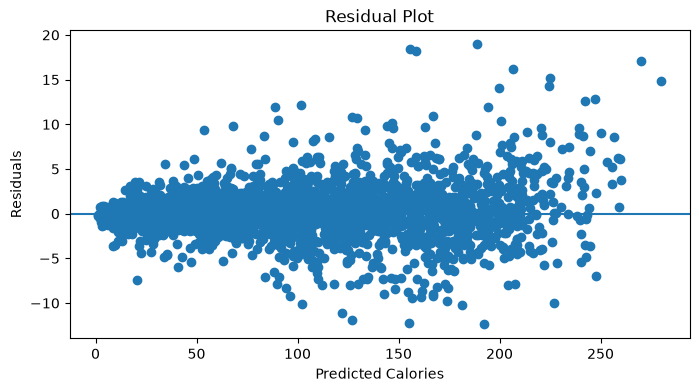

In [69]:
plt.figure(figsize=(8, 4))

plt.scatter(rf_pred, residuals)

plt.axhline(y=0)

plt.xlabel("Predicted Calories")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()

In [70]:
residuals = ytest - rf_pred

print("Mean Residual:", residuals.mean())
print("Mean Absolute Error:", abs(residuals).mean())
print("Maximum Error:", abs(residuals).max())

Mean Residual: 0.19304666666666642
Mean Absolute Error: 1.7173133333333332
Maximum Error: 18.930000000000007


#finalize model

The mean residual of 0.193 is especially reassuring. Since it is close to zero, your model isn't consistently overpredicting or underpredicting.

And your MAE matches the Random Forest result you already obtained:

MAE = 1.7173 calories

Your model evaluation is now complete 🎉

You have checked your model from several angles:

Test R²: 0.9982
Test RMSE: 2.683
Test MAE: 1.717
5-Fold CV Mean R²: 0.9979
CV Standard Deviation: 0.0002
Feature Importance: completed
Actual vs Predicted: completed
Residual Analysis: completed

So don't do more model evaluation right now.

In [71]:
final_rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

final_rf_model.fit(x, y)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [72]:
import pickle

with open("calories_model.pkl", "wb") as file:
    pickle.dump(final_rf_model, file)

print("Final model saved successfully!")

Final model saved successfully!


In [73]:
with open("calories_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

sample_prediction = loaded_model.predict(x.iloc[[0]])

print("Predicted Calories:", sample_prediction[0])
print("Actual Calories:", y.iloc[0])

Predicted Calories: 230.36
Actual Calories: 231.0
